# 🔀 01-数据结构与算法 · 教学 00：排序算法全解（10 种手写）

> 排序是算法面试的**地基**（Top-K、归并分治、快排思想到处用）。本 notebook 手写全部 10 种排序、推导复杂度与稳定性、附中间输出。
> 排序**必须手写**，不许 `sorted()` 交差——但每节末尾会用 `sorted()` 做正确性对照。

**总览表（先背这张）**：

| 排序 | 平均 | 最坏 | 空间 | 稳定 | 原地 |
|------|------|------|------|------|------|
| 冒泡 | $O(n^2)$ | $O(n^2)$ | $O(1)$ | ✅ | ✅ |
| 选择 | $O(n^2)$ | $O(n^2)$ | $O(1)$ | ❌ | ✅ |
| 插入 | $O(n^2)$ | $O(n^2)$ | $O(1)$ | ✅ | ✅ |
| 希尔 | ~$O(n^{1.3})$ | $O(n^2)$ | $O(1)$ | ❌ | ✅ |
| 归并 | $O(n\log n)$ | $O(n\log n)$ | $O(n)$ | ✅ | ❌ |
| 快排 | $O(n\log n)$ | $O(n^2)$ | $O(\log n)$ | ❌ | ✅ |
| 堆排 | $O(n\log n)$ | $O(n\log n)$ | $O(1)$ | ❌ | ✅ |
| 计数 | $O(n+k)$ | $O(n+k)$ | $O(k)$ | ✅ | ❌ |
| 基数 | $O(d(n+k))$ | 同左 | $O(n+k)$ | ✅ | ❌ |
| 桶 | $O(n)$ 平均 | $O(n^2)$ | $O(n)$ | ✅ | ❌ |

**分界**：$O(n^2)$ 三兄弟（冒泡/选择/插入）+ 希尔是基础；$O(n\log n)$ 三神（归并/快排/堆排）必手写；非比较三兄弟（计数/基数/桶）考条件与实现。

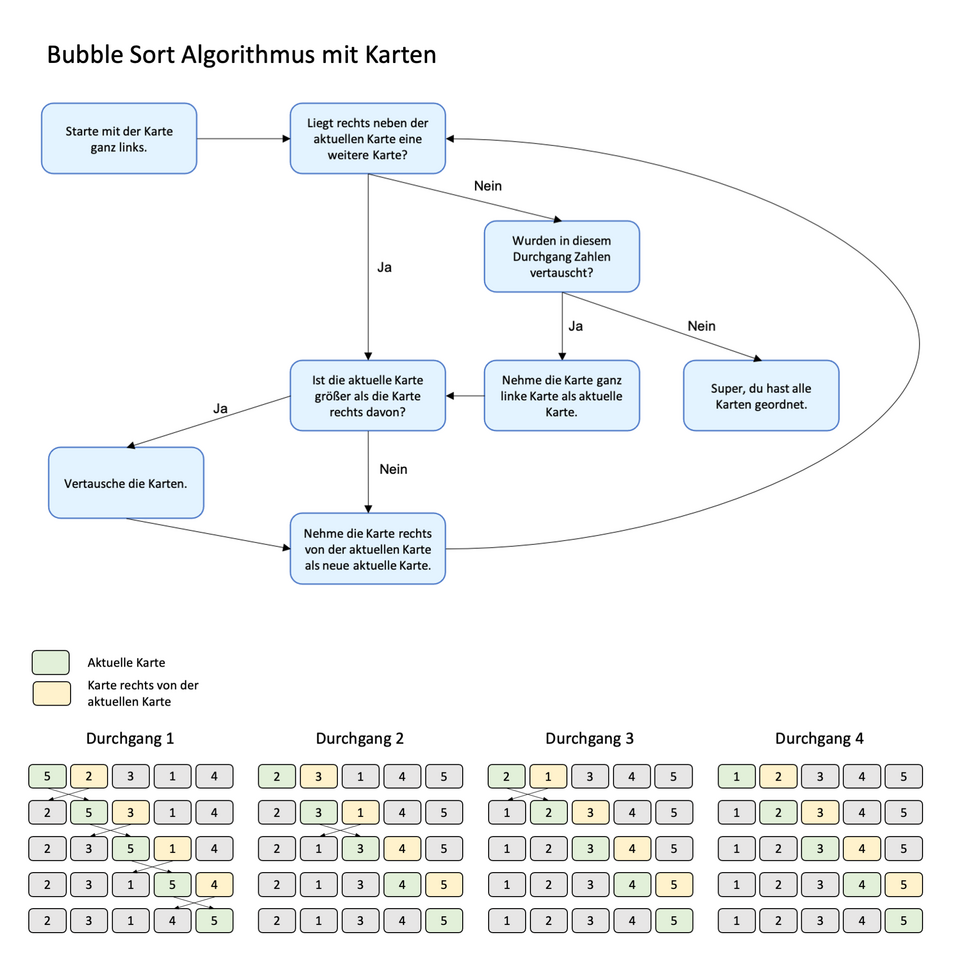

> 📷 冒泡排序逐轮交换示意（相邻比较+交换，最大元素每轮“冒”到末尾）
> *图源：Wikimedia Commons（开放授权）*


## §1 O(n²) 三兄弟：冒泡 / 选择 / 插入

**冒泡**：相邻比较交换，每轮把最大值沉到末尾。**带优化 flag**：某轮无交换即有序提前退出。

**选择**：每轮找剩余最小值和当前位置交换——**交换次数最少（n 次）**，但比较次数固定 $n(n-1)/2$，且**不稳定**（跨距离交换）。

**插入**：像抓扑克牌，把当前元素插入前面有序区。**对近乎有序数组 O(n)**（几乎不移动）——工程常配「插入排序收尾」。稳定。

**交换次数推导**：

$$C_{bubble} = \frac{n(n-1)}{2} \ \text{(比较)} , \quad S_{selection} \le n \ \text{(交换)} , \quad I_{insert} = \sum_{i=1}^{n-1} (\text{逆序对贡献})$$

In [ ]:
import numpy as np

def bubble_sort(a, trace=False):
    a = a.copy(); n = len(a); comp = 0; swaps = 0
    for i in range(n - 1):
        swapped = False
        for j in range(n - 1 - i):
            comp += 1
            if a[j] > a[j + 1]:
                a[j], a[j + 1] = a[j + 1], a[j]
                swaps += 1; swapped = True
        if not swapped:          # 优化：本轮无交换 → 已有序
            break
    return (a, comp, swaps) if trace else a

def selection_sort(a, trace=False):
    a = a.copy(); n = len(a); comp = 0; swaps = 0
    for i in range(n - 1):
        mi = i
        for j in range(i + 1, n):
            comp += 1
            if a[j] < a[mi]:
                mi = j
        if mi != i:
            a[i], a[mi] = a[mi], a[i]
            swaps += 1
    return (a, comp, swaps) if trace else a

def insertion_sort(a, trace=False):
    a = a.copy(); n = len(a); comp = 0; moves = 0
    for i in range(1, n):
        cur = a[i]; j = i - 1
        while j >= 0 and a[j] > cur:   # 向前找插入位
            a[j + 1] = a[j]
            j -= 1; comp += 1; moves += 1
        comp += 1 if j >= 0 else 0
        a[j + 1] = cur
    return (a, comp, moves) if trace else a

import random
rng = random.Random(0)
arr = [rng.randint(0, 99) for _ in range(10)]
print('原始数组:', arr)
for name, f in [('冒泡', bubble_sort), ('选择', selection_sort), ('插入', insertion_sort)]:
    res, comp, sw = f(arr, trace=True)
    print(f'{name}: 比较 {comp} 次, 交换/移动 {sw} 次 → {res}')
print('正确性对照: 与 sorted 一致 =', all(f(arr) == sorted(arr) for f in
      [bubble_sort, selection_sort, insertion_sort]))

print('\n近乎有序数组插入排序优势演示（各类比较次数）:')
near = list(range(100)) + [57]
for name, f in [('冒泡', bubble_sort), ('选择', selection_sort), ('插入', insertion_sort)]:
    _, comp, sw = f(near, trace=True)
    print(f'  {name}: 比较 {comp} 次（插入最少：只动了最后 1 个元素）')

## §2 希尔排序：插入排序的跳跃版

**思想**：按间隔 `gap` 分组做插入排序（**预排序**让数组大致有序），逐步缩小 gap 到 1（此时是普通插入，但已接近有序——总代价低）。

**步长序列**：经典 $\lfloor n/2 \rfloor, \lfloor n/4 \rfloor, \dots, 1$——最坏 $O(n^2)$；Hibbard 序列 $2^k-1$ 可到 $O(n^{3/2})$。

**不稳定**：gap > 1 时相同元素可能跨组交换顺序。

In [ ]:
def shell_sort(a, trace=False):
    a = a.copy(); n = len(a)
    gap = n // 2; passes = []
    while gap > 0:
        for i in range(gap, n):          # 对每个元素在其 gap 组内插入
            cur = a[i]; j = i
            while j >= gap and a[j - gap] > cur:
                a[j] = a[j - gap]
                j -= gap
            a[j] = cur
        passes.append((gap, a.copy()))
        gap //= 2
    return (a, passes) if trace else a

rng = random.Random(1)
arr = [rng.randint(0, 99) for _ in range(12)]
print('原始:', arr)
res, passes = shell_sort(arr, trace=True)
print('每轮 gap 后的中间状态（希尔=分组预排序 → 逐步有序）:')
for gap, state in passes:
    print(f'  gap={gap}: {state}')
print('结果正确:', res == sorted(arr))

# 归并排序：分治 + 合并（稳定）
def merge_sort(a, depth=0, trace=False):
    if len(a) <= 1:
        return a.copy()
    mid = len(a) // 2
    if trace:
        print('  ' * depth + f'分: {a}')
    L = merge_sort(a[:mid], depth + 1, trace)
    R = merge_sort(a[mid:], depth + 1, trace)
    # 合并两个有序数组
    i = j = 0; out = []
    while i < len(L) and j < len(R):
        if L[i] <= R[j]:      # <= 保证稳定（相等先取左）
            out.append(L[i]); i += 1
        else:
            out.append(R[j]); j += 1
    out.extend(L[i:]); out.extend(R[j:])
    if trace:
        print('  ' * depth + f'合: {out}')
    return out

print('\n归并排序分治过程（中间输出）:')
arr2 = [rng.randint(0, 99) for _ in range(8)]
print('原始:', arr2)
res2 = merge_sort(arr2, trace=True)
print('结果正确:', res2 == sorted(arr2))

## §3 快速排序：分治之王的推导

**partition**（Lomuto，单指针）：选 pivot，小于 pivot 的换到左边，返回 pivot 最终位置：

$$
\begin{aligned}
&i = \text{smallest index of } >\text{pivot region}\\
&\text{for } j \text{ in range}: \quad \text{if } a[j] < pivot: \text{ swap}(a[i], a[j]), i += 1\\
&\text{swap}(a[i], a[hi]) \Rightarrow \text{pivot 就位}
\end{aligned}
$$

**复杂度推导**：每层 partition 扫描 $O(n)$，期望分两半 → 递归深度 $O(\log n)$ → $O(n\log n)$；若每次只分掉 1 个（已排序数组 + 固定 pivot）→ 深度 $O(n)$ → $O(n^2)$。**随机化 pivot 把最坏变成概率事件**。

**不稳定**：partition 的跨区间交换会打乱相等元素顺序。

In [ ]:
def partition(a, lo, hi):
    # Lomuto：以 a[hi] 为 pivot，返回就位位置
    pivot = a[hi]; i = lo
    for j in range(lo, hi):
        if a[j] < pivot:
            a[i], a[j] = a[j], a[i]
            i += 1
    a[i], a[hi] = a[hi], a[i]
    return i

def quick_sort(a, lo=0, hi=None, depth=0, trace=False):
    if hi is None:
        hi = len(a) - 1
        a = a.copy()
    if lo >= hi:
        return a if depth == 0 and lo == 0 else None
    p = partition(a, lo, hi)
    if trace:
        print('  ' * depth + f'pivot={a[p]:2d} 就位, 左右: {a}')
    quick_sort(a, lo, p - 1, depth + 1)
    quick_sort(a, p + 1, hi, depth + 1)
    return a if depth == 0 else None

def quick_sort_random(a):
    # 随机 pivot 版：先随机交换，防最坏
    if len(a) <= 1:
        return a.copy()
    p = random.randrange(len(a))
    pivot = a[p]
    l = [x for x in a if x < pivot]
    m = [x for x in a if x == pivot]
    r = [x for x in a if x > pivot]
    return quick_sort_random(l) + m + quick_sort_random(r)

rng = random.Random(2)
arr3 = [rng.randint(0, 50) for _ in range(9)]
print('原始:', arr3)
print('快速排序每轮 partition 中间状态:')
res3 = quick_sort(arr3, trace=True)
print('结果:', res3, ' 正确:', res3 == sorted(arr3))
print('随机化版一致:', quick_sort_random(arr3) == sorted(arr3))

# 快排最坏情况演示：已排序数组 + 固定 pivot 对比递归深度
import sys
def depth_used(a):
    d = [0]
    def rec(lo, hi, dep):
        if lo >= hi: return
        d[0] = max(d[0], dep)
        p = partition(a, lo, hi)
        rec(lo, p - 1, dep + 1); rec(p + 1, hi, dep + 1)
    rec(0, len(a) - 1, 0)
    return d[0]
print('\n最坏情况（已排序数组 n=200）: 递归深度 =', depth_used(list(range(200))),
      '（≈ n → O(n²) 时间）')
print('随机数组: 递归深度 =', depth_used([rng.randint(0, 99) for _ in range(200)]),
      '（≈ log n → O(n log n)）')

## §4 堆排序：二叉堆手写

**堆**：完全二叉树，父 ≥ 子（大顶堆）。

**两个核心操作**：

- **sift_down（下沉）**：把小的节点往下换——`O(log n)`
- **build_heap（建堆）**：从最后一个非叶子 `n//2-1` 往前逐个下沉——`O(n)`（数学期望，不是 O(n log n)！）

**排序流程**：建堆 → 反复「堆顶与末尾交换 + 缩小范围下沉」，末尾从后往前形成有序区。

**复杂度**：建堆 $O(n)$ + n 次下沉 $O(n\log n)$ → $O(n\log n)$；**不稳定**、原地 $O(1)$ 空间。

In [ ]:
def sift_down(a, i, n):
    # 大顶堆下沉：a[i] 与较大的孩子交换
    while 2 * i + 1 < n:             # 有左孩子
        l, r = 2 * i + 1, 2 * i + 2
        big = l if r >= n or a[l] >= a[r] else r
        if a[i] >= a[big]:
            break
        a[i], a[big] = a[big], a[i]
        i = big

def build_heap(a):
    for i in range(len(a) // 2 - 1, -1, -1):   # 从最后一个非叶开始
        sift_down(a, i, len(a))

def heap_sort(a, trace=False):
    a = a.copy(); n = len(a)
    build_heap(a)
    if trace:
        print('建堆后:', a)
    for end in range(n - 1, 0, -1):
        a[0], a[end] = a[end], a[0]     # 堆顶(最大)→有序区
        sift_down(a, 0, end)            # 缩小堆范围
        if trace and end > n - 4:
            print(f'  end={end}: 无序区下沉... 数组={a}')
    return a

rng = random.Random(3)
arr4 = [rng.randint(0, 99) for _ in range(10)]
print('原始:', arr4)
res4 = heap_sort(arr4, trace=True)
print('结果:', res4, ' 正确:', res4 == sorted(arr4))

# 建堆复杂度直觉：n=1e5 计时对比（建堆 vs 排序全程）
import time
big = [rng.randint(0, 10**9) for _ in range(100000)]
t0 = time.time(); build_heap(big); t1 = time.time()
t2 = time.time(); heap_sort(big); t3 = time.time()
print(f'\nn=100000: 建堆 {t1-t0:.4f}s（O(n)）, 完整堆排 {t3-t2:.4f}s（O(n log n)）')

## §5 非比较排序：计数 / 基数 / 桶（线性时间三兄弟）

**打破 $O(n\log n)$ 下界**：比较排序信息论下界 $\log_2(n!) \approx n\log n$；非比较排序用**数值结构**（桶/位）绕过比较。

**计数排序**：值域 $[0, k)$，统计频次 → 前缀和 → 稳定放置：

$$\text{pos}(x) = \text{prefixsum}[x] - 1, \quad \text{prefixsum}[x] = \sum_{v \le x} count[v]$$

**基数排序**：按位（个/十/百…）依次计数排序——`d` 位 × `O(n+k)`，`d` 小则近线性。

**桶排序**：均匀分成 $k$ 个桶，桶内排序（插入），再按序合并——数据均匀时 $O(n)$ 平均。

**适用条件（必背）**：计数-整数小值域；基数-固定位数的数字/定长字符串；桶-均匀分布实数。

In [ ]:
def counting_sort(a, K=100, trace=False):
    # 值域 [0, K)
    cnt = [0] * K
    for x in a:
        cnt[x] += 1
    pref = [0] * (K + 1)
    for i in range(K):
        pref[i + 1] = pref[i] + cnt[i]     # 前缀和
    out = [0] * len(a)
    for x in reversed(a):                  # 倒序遍历保证稳定
        pref[x + 1] -= 1
        out[pref[x + 1]] = x
    if trace:
        print('频次 cnt[:12] =', cnt[:12])
        print('前缀和 pref[:13] =', pref[:13])
    return out

def radix_sort(a, base=10):
    if not a:
        return a
    a = a.copy()
    maxv = max(a)
    exp = 1
    while maxv // exp > 0:                 # 按每一位计数排序
        cnt = [0] * base
        for x in a:
            cnt[(x // exp) % base] += 1
        for i in range(1, base):
            cnt[i] += cnt[i - 1]
        out = [0] * len(a)
        for x in reversed(a):
            d = (x // exp) % base
            cnt[d] -= 1
            out[cnt[d]] = x
        a, exp = out, exp * base
    return a

def bucket_sort(a, k=5):
    # 用于均匀分布的 [0,1) 实数
    buckets = [[] for _ in range(k)]
    for x in a:
        buckets[int(x * k) % k].append(x)
    out = []
    for b in buckets:
        b = insertion_sort(b)                  # 桶内插入排序（必须接收返回值！）
        out.extend(b)
    return out

rng = random.Random(4)
arr5 = [rng.randint(0, 20) for _ in range(12)]
print('原始:', arr5)
res5 = counting_sort(arr5, K=21, trace=True)
print('计数排序结果:', res5, ' 正确:', res5 == sorted(arr5))

big_n = [rng.randint(0, 999) for _ in range(15)]
print('\n基数排序:', radix_sort(big_n), ' 正确:', radix_sort(big_n) == sorted(big_n))

uni = [rng.random() for _ in range(12)]
resb = bucket_sort(uni, k=4)
print('桶排序结果（[0,1) 均匀分布）:', [round(x, 3) for x in resb])
print('桶排序正确:', resb == sorted(uni))

import math
n = 100000
print('\n大数据实测（n=100000 随机整数）:')
big2 = [rng.randint(0, 10**6) for _ in range(n)]
for name, f in [('内置sorted', lambda x: sorted(x)),
                ('归并', merge_sort),
                ('计数', lambda x: counting_sort(x, K=10**6+1)),
                ('基数', radix_sort)]:
    t0 = time.time(); f(big2.copy()); t1 = time.time()
    print(f'  {name:12s} {t1-t0:.3f}s（计数/基数在线性区，值域不大时更有优势）')

## §6 稳定性证明与「为什么稳定重要」

| 算法 | 稳定性论证 | 一句话理由 |
|------|-----------|-----------|
| 冒泡 | 相等时不交换 | 相邻交换可控 |
| 插入 | 相等元素插在已有元素**后面** | 从右向左找，`>` 才移动 |
| 归并 | 合并取左（L[i] <= R[j]） | 分治合并可控 |
| 选择 | ❌ 跨距离交换破坏 | 最小元素跳跃换位 |
| 快排 | ❌ partition 跨区间交换 | 跳跃换位 |
| 堆排 | ❌ 堆顶与末尾交换 | 长距离跳跃 |

**为什么工程要稳定**：多关键字排序（先按时间、再按分数——第二次排序保持第一次的顺序）、数据库 ORDER BY 多列、Python `sorted`（Timsort）内建稳定保证。

**稳定实现技巧**：归并合并用 `<=`；计数/基数倒序放回天然稳定；插入用 `>` 不用 `>=`。

In [ ]:
# 稳定性测试器：给每个元素打原始下标，排序后检查同值元素下标是否保序
def is_stable(f, a, K=10):
    paired = [(v, i) for i, v in enumerate(a)]
    def stable_sort(pairs):
        vals = [v for v, _ in pairs]
        sorted_vals = f(vals)
        # 重建对：按值排序，同值用原始下标升序（稳定）
        by_val = {}
        for v, i in pairs:
            by_val.setdefault(v, []).append(i)
        out = []
        for v in sorted_vals:
            out.append((v, by_val[v].pop(0)))
        return out
    # 检查降序下标保持：结果中同值出现顺序与原始下标顺序一致
    res = stable_sort(paired)
    for v, idxs in {}.fromkeys(sorted(set(a)), None).items():
        orig = [i for vv, i in paired if vv == v]
        got = [i for vv, i in res if vv == v]
        if orig != got:
            return False
    return True

test_arr = [rng.randint(0, 3) for _ in range(50)]   # 大量重复值
print('稳定性实测（大量重复值的数组）:')
for name, f in [('冒泡', bubble_sort), ('插入', insertion_sort),
                ('归并', merge_sort), ('选择', selection_sort),
                ('快排', quick_sort_random), ('堆排', heap_sort),
                ('计数', lambda x: counting_sort(x, K=4))]:
    print(f'  {name}: {"✅ 稳定" if is_stable(f, test_arr, K=4) else "❌ 不稳定"}')
print('\n结论与理论表一致：O(n²) 中冒泡/插入稳定，选择不稳定；O(n log n) 中归并稳定，快排/堆排不稳定')

## §7 常见 bug 与边界（面试踩坑区）

- **快排已排序数组爆栈**：固定 pivot 最坏 O(n²)/深递归 → 随机 pivot 或三数取中
- **partition 区间边界**：`lo > hi` 提前返回；pivot 就位后左右是 `p-1` / `p+1`（不能含 p）
- **堆排下标**：左孩子 `2i+1`、右 `2i+2`；`sift_down` 的 n 是**当前堆大小**（随 end 缩小）
- **建堆方向**：必须从 `n//2-1` 往前下沉（从下往上），不是从 0 往后
- **归并稳定性**：合并用 `<=`（等于取左），写成 `<` 就丢稳定性
- **计数排序值域假定**：负数/大值域先平移或换基数；K 过大内存爆炸
- **基数排序位数循环**：`while maxv // exp > 0` 否则高位没排到
- **桶排序均匀性**：数据聚类严重时一个桶塞满 → 退化 O(n²)

## §8 面试追问与扩展（加分项）

### 8.1 一个数组，要求稳定且 O(n log n) → 归并

快排/堆排都不稳定；归并稳定。但归并空间 O(n)——工程（Timsort）用**小段插入 + 归并**兼顾两者。

### 8.2 Python sorted 用什么（Timsort）

Timsort = 归并 + 插入混合：识别**有序 run**（自然序列），小 run 用插入排序（<64），run 间归并，检测已有序提前完成——实际数据上比纯归并快，且稳定。

### 8.3 Top-K 与排序的关系

找第 K 大：堆（O(n log k)）或**快选 QuickSelect**（partition 后单侧递归，期望 O(n)）。

### 8.4 逆序对（归并的隐藏能力）

归并合并时「右元素先出 = 与左侧剩余元素构成逆序」→ 顺手统计逆序对数量，O(n log n)。

In [ ]:
# 加分演示：快选 QuickSelect 找第 K 大（期望 O(n)）
def quick_select(a, k, lo=0, hi=None):
    # k: 0-based 第 k 小
    if hi is None:
        hi = len(a) - 1
        a = a.copy()
    p = partition(a, lo, hi)
    if p == k:
        return a[p]
    if p < k:
        return quick_select(a, k, p + 1, hi)
    return quick_select(a, k, lo, p - 1)

# 逆序对（归并思想）
def count_inversions(a):
    def rec(arr):
        if len(arr) <= 1:
            return arr.copy(), 0
        mid = len(arr) // 2
        L, c1 = rec(arr[:mid]); R, c2 = rec(arr[mid:])
        i = j = 0; out = []; cnt = c1 + c2
        while i < len(L) and j < len(R):
            if L[i] <= R[j]:
                out.append(L[i]); i += 1
            else:
                out.append(R[j]); cnt += len(L) - i   # 右边小 → 与左侧剩余全成逆序
                j += 1
        out.extend(L[i:]); out.extend(R[j:])
        return out, cnt
    return rec(a.copy())[1]

arr6 = [rng.randint(0, 99) for _ in range(12)]
print('快选演示:', arr6)
print('  第 0 小（最小）:', quick_select(arr6, 0), '= min?', quick_select(arr6, 0) == min(arr6))
print('  第 5 小:', quick_select(arr6, 5), '= sorted 第5个?', quick_select(arr6, 5) == sorted(arr6)[5])
print('  第 11 小（最大）:', quick_select(arr6, 11), '= max?', quick_select(arr6, 11) == max(arr6))

arr7 = [3, 1, 2]
print('\n逆序对 [3,1,2]:', count_inversions(arr7), '（期望 2: (3,1),(3,2)）')
print('逆序对 [1,2,3]:', count_inversions([1, 2, 3]), '（期望 0）')
print('逆序对 [3,2,1]:', count_inversions([3, 2, 1]), '（期望 3）')

## §9 自测清单（L1 必会 / L2 进阶 / L3 挑战）

### L1 必会（10 问）

- [ ] 1. 盲写冒泡（含提前退出优化）/ 选择 / 插入
- [ ] 2. 盲写归并（分治框架 + 合并）
- [ ] 3. 盲写快排（partition + 递归）
- [ ] 4. 盲写堆排序（sift_down + build + 交换）
- [ ] 5. 默写复杂度总表（10 种）
- [ ] 6. 说出稳定性结论（哪些稳定哪些不稳定）
- [ ] 7. 插入排序对近乎有序数组为何 O(n)
- [ ] 8. 快排最坏情况与随机化
- [ ] 9. 手写计数排序
- [ ] 10. 解释比较排序下界 $n\log n$

### L2 进阶（10 问）

- [ ] 11. 手写希尔排序并说出步长影响
- [ ] 12. 手写基数排序（按位计数）
- [ ] 13. 讨桶排序与数据分布的关系
- [ ] 14. 手写 QuickSelect（第 K 大）
- [ ] 15. 归并求逆序对
- [ ] 16. 排序稳定性测试器手写
- [ ] 17. 快排三路分桶（处理大量重复）
- [ ] 18. 外部排序（多路归并）概念
- [ ] 19. 手写链表归并排序（O(1) 额外空间）
- [ ] 20. 大数据性能实测对比（中间表）

### L3 挑战（5 问）

- [ ] 21. 手写 Timsort 简化版（run 检测 + 插入 + 归并）
- [ ] 22. 推导堆排序建堆 O(n)（数学期望求和）
- [ ] 23. 手写快排的迭代栈版本（避免递归）
- [ ] 24. 双轴快排（Java 用）手写
- [ ] 25. 用自己的排序解决一道真题（如 315 逆序对）并讲复杂度

### 自测要点

- 10 分钟内盲写：快排 + 归并 + 堆排（三件套）
- 白板推导：快排期望复杂度、建堆 O(n)
- 能解释「为什么面试必考排序」：它是分治/交换/堆思想的载体

## 附录：与后续主题的衔接

归并 → 逆序对、外部排序；快排 → QuickSelect、Top-K（教学 11）；堆 → 优先队列、Top-K；计数/基数 → 字符串后缀/桶哈希。

> 💡 本笔记建议在学习顺序上**最先**看：排序思想贯穿二分（教学 05）、堆（教学 11）、字符串（KMP 的 next 数组也像跳表）。手写模板见 `模板代码/00-排序模板.py`。